In [1]:
!pip install -q "numpy<2" "matplotlib<3.8"

In [2]:
!pip install -q transformers bitsandbytes accelerate datasets netcal wandb lm-eval scikit-learn trl

In [3]:
import wandb
wandb.login()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: sagarsharma-ai (sagarsharma-ai-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [4]:
import wandb

wandb.init(
    project="Order_of_Operations",
    name="pipeline_A_ptq",
    config={
        "model": "Gemma-2-2B-Instruct",
        "quantization": "4bit_nf4",
        "pipeline": "PTQ"
    }
)

In [5]:
from huggingface_hub import login
login()

### Gemma-2-2B-IT

In [9]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

tokenizer_it = AutoTokenizer.from_pretrained("google/gemma-2-2b-it")
model_it = AutoModelForCausalLM.from_pretrained(
    "google/gemma-2-2b-it",
    quantization_config=bnb_config,
    device_map="auto",
)

print(f"Loaded: {model_it.device}")
print(f"Memory: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

Loaded: cuda:0
Memory: 2.25 GB


In [12]:
inputs = tokenizer_it(
    "The capital of India is",
    return_tensors="pt"
).to("cuda")

with torch.no_grad():
    outputs = model_it.generate(**inputs, max_new_tokens=10)

print(tokenizer_it.decode(outputs[0], skip_special_tokens=True))

The capital of India is:

a) Mumbai
b) Delhi



In [14]:
from lm_eval.models.huggingface import HFLM

lm = HFLM(
    pretrained=model_it,
    tokenizer=tokenizer_it,
    batch_size=8,
)

In [15]:
from lm_eval import evaluator

results = evaluator.simple_evaluate(
    model=lm,
    tasks=["arc_challenge"],
    num_fewshot=5,
    batch_size=8,
    limit=0.1,
)

README.md: 0.00B [00:00, ?B/s]

ARC-Challenge/train-00000-of-00001.parqu(…):   0%|          | 0.00/190k [00:00<?, ?B/s]

ARC-Challenge/test-00000-of-00001.parque(…):   0%|          | 0.00/204k [00:00<?, ?B/s]

ARC-Challenge/validation-00000-of-00001.(…):   0%|          | 0.00/55.7k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1119 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1172 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/299 [00:00<?, ? examples/s]

Running loglikelihood requests: 100%|██████████| 472/472 [01:19<00:00,  5.96it/s]


In [24]:
from lm_eval import evaluator

wandb.init(
    project="Order_of_Operations",
    name="gemma-2-2b-it_full",
    id="pipeline_A_ptq_full",
    resume="allow",
)

results = evaluator.simple_evaluate(
    model=lm,
    tasks=["arc_challenge"],
    num_fewshot=0,
    batch_size=2,
    limit=None,
    write_out=True,
)

"arc_challenge/acc,none",▁▁
"arc_challenge/acc_norm,none",▁▁
"arc_challenge/acc_norm_stderr,none",▁▁
"arc_challenge/acc_stderr,none",▁▁
"arc_challenge/acc,none",0.48976
"arc_challenge/acc_norm,none",0.52133
"arc_challenge/acc_norm_stderr,none",0.0146
"arc_challenge/acc_stderr,none",0.01461
arc_challenge/alias,arc_challenge


Running loglikelihood requests: 100%|██████████| 4687/4687 [06:37<00:00, 11.80it/s]


In [26]:
import json
import os
import wandb

def safe_json(obj):
    try:
        return str(obj)
    except:
        return None

output_dir = "./results/pipeline_a"
os.makedirs(output_dir, exist_ok=True)

with open(f"{output_dir}/results.json", "w") as f:
    json.dump(results["results"], f, indent=2)

with open(f"{output_dir}/full_output.json", "w") as f:
    json.dump(results, f, indent=2, default=safe_json)

if "samples" in results:
    with open(f"{output_dir}/samples.json", "w") as f:
        json.dump(results["samples"], f, indent=2, default=safe_json)

flat_results = {}
for task, metrics in results["results"].items():
    for k, v in metrics.items():
        flat_results[f"{task}/{k}"] = v

wandb.log(flat_results)

wandb.save(f"{output_dir}/results.json")
wandb.save(f"{output_dir}/full_output.json")

if os.path.exists(f"{output_dir}/samples.json"):
    wandb.save(f"{output_dir}/samples.json")

print("Logged + saved everything.")

Logged + saved everything.


In [27]:
import json

with open("./results/pipeline_a/samples.json") as f:
    samples = json.load(f)

# Look at one sample
sample = samples["arc_challenge"][0]
print(json.dumps(sample, indent=2, default=str))

{
  "doc_id": 0,
  "doc": {
    "id": "Mercury_7175875",
    "question": "An astronomer observes that a planet rotates faster after a meteorite impact. Which is the most likely effect of this increase in rotation?",
    "choices": {
      "text": [
        "Planetary density will decrease.",
        "Planetary years will become longer.",
        "Planetary days will become shorter.",
        "Planetary gravity will become stronger."
      ],
      "label": [
        "A",
        "B",
        "C",
        "D"
      ]
    },
    "answerKey": "C"
  },
  "target": 2,
  "arguments": [
    [
      "Question: An astronomer observes that a planet rotates faster after a meteorite impact. Which is the most likely effect of this increase in rotation?\nAnswer:",
      " Planetary density will decrease."
    ],
    [
      "Question: An astronomer observes that a planet rotates faster after a meteorite impact. Which is the most likely effect of this increase in rotation?\nAnswer:",
      " Planetar

In [28]:
import numpy as np
from scipy.special import softmax

confidences = []
correct = []

for sample in samples["arc_challenge"]:
    # Extract log-likelihoods for each choice
    logprobs = np.array([r[0] for r in sample["filtered_resps"]])

    # Softmax → probabilities
    probs = softmax(logprobs)

    # Predicted = argmax, confidence = max prob
    pred = int(np.argmax(probs))
    conf = float(probs[pred])
    label = int(sample["target"])

    confidences.append(conf)
    correct.append(int(pred == label))

confidences = np.array(confidences)
correct = np.array(correct)

print(f"Samples: {len(confidences)}")
print(f"Accuracy: {correct.mean():.4f}")
print(f"Mean confidence: {confidences.mean():.4f}")
print(f"Overconfident wrong predictions: {(confidences[correct==0] > 0.7).mean():.4f}")

Samples: 1172
Accuracy: 0.4898
Mean confidence: 0.8649
Overconfident wrong predictions: 0.7458


In [29]:
from netcal.metrics import ECE

ece = ECE(bins=15)
ece_score = ece.measure(confidences, correct)

print(f"ECE: {ece_score:.4f}")

ECE: 0.3751


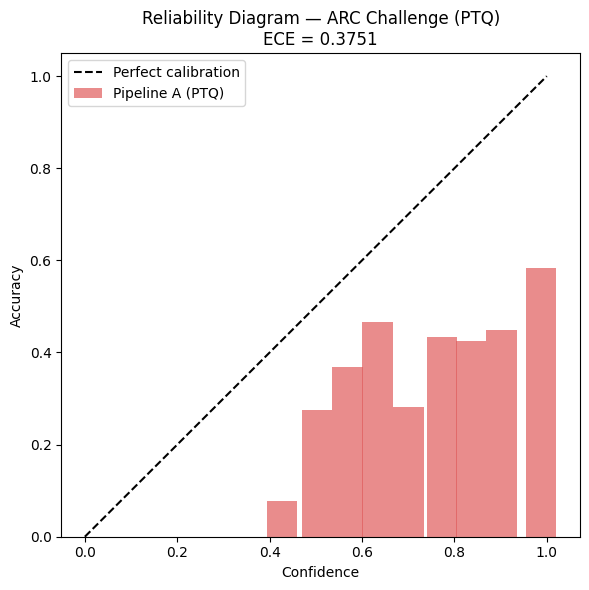

In [30]:
import matplotlib.pyplot as plt

bins = np.linspace(0, 1, 16)
bin_accs, bin_confs = [], []

for lo, hi in zip(bins[:-1], bins[1:]):
    mask = (confidences >= lo) & (confidences < hi)
    if mask.sum() == 0:
        continue
    bin_accs.append(correct[mask].mean())
    bin_confs.append(confidences[mask].mean())

bin_accs = np.array(bin_accs)
bin_confs = np.array(bin_confs)

plt.figure(figsize=(6, 6))
plt.bar(bin_confs, bin_accs, width=1/15, alpha=0.7, color="#E05C5C", label="Pipeline A (PTQ)")
plt.plot([0,1],[0,1],"k--", label="Perfect calibration")
plt.xlabel("Confidence")
plt.ylabel("Accuracy")
plt.title(f"Reliability Diagram — ARC Challenge (PTQ)\nECE = {ece_score:.4f}")
plt.legend()
plt.tight_layout()
plt.savefig("reliability_ptq_arc.png", dpi=150)
plt.show()

In [31]:
wandb.log({
    "arc_challenge/ece": ece_score,
    "arc_challenge/mean_confidence": float(confidences.mean()),
    "arc_challenge/overconfidence_rate": float((confidences[correct==0] > 0.7).mean()),
    "arc_challenge/reliability_diagram": wandb.Image("reliability_ptq_arc.png"),
})

In [32]:
results_all = evaluator.simple_evaluate(
    model=lm,
    tasks=["mmlu", "truthfulqa_mc2"],
    num_fewshot=0,
    batch_size=2,
    limit=0.1,        # 10% for now — MMLU is huge
    write_out=True,
)

README.md: 0.00B [00:00, ?B/s]

dataset_infos.json: 0.00B [00:00, ?B/s]

world_religions/test-00000-of-00001.parq(…):   0%|          | 0.00/18.9k [00:00<?, ?B/s]

world_religions/validation-00000-of-0000(…):   0%|          | 0.00/4.94k [00:00<?, ?B/s]

world_religions/dev-00000-of-00001.parqu(…):   0%|          | 0.00/3.30k [00:00<?, ?B/s]

...

Generating dev split:   0%|          | 0/5 [00:00<?, ? examples/s]

README.md: 0.00B [00:00, ?B/s]

multiple_choice/validation-00000-of-0000(…):   0%|          | 0.00/271k [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/817 [00:00<?, ? examples/s]

Running loglikelihood requests: 100%|██████████| 6337/6337 [05:57<00:00, 17.71it/s]


In [33]:
for task, metrics in results_all["results"].items():
    acc = metrics.get("acc,none") or metrics.get("acc_norm,none")
    print(f"{task}: {acc:.4f}")

mmlu: 0.5636
mmlu_humanities: 0.5146
mmlu_formal_logic: 0.4615
mmlu_high_school_european_history: 0.6471
mmlu_high_school_us_history: 0.6667
mmlu_high_school_world_history: 0.8750
mmlu_international_law: 0.9231
mmlu_jurisprudence: 0.5455
mmlu_logical_fallacies: 0.7647
mmlu_moral_disputes: 0.4857
mmlu_moral_scenarios: 0.2444
mmlu_philosophy: 0.7188
mmlu_prehistory: 0.4242
mmlu_professional_law: 0.4740
mmlu_world_religions: 0.7778
mmlu_other: 0.6215
mmlu_business_ethics: 0.4000
mmlu_clinical_knowledge: 0.7037
mmlu_college_medicine: 0.6667
mmlu_global_facts: 0.5000
mmlu_human_aging: 0.5217
mmlu_management: 0.9091
mmlu_marketing: 0.6667
mmlu_medical_genetics: 0.7000
mmlu_miscellaneous: 0.7342
mmlu_nutrition: 0.8065
mmlu_professional_accounting: 0.3103
mmlu_professional_medicine: 0.4286
mmlu_virology: 0.4706
mmlu_social_sciences: 0.6645
mmlu_econometrics: 0.2500
mmlu_high_school_geography: 0.7500
mmlu_high_school_government_and_politics: 0.7500
mmlu_high_school_macroeconomics: 0.6154
mmlu_h

In [34]:
print(list(results_all["samples"].keys()))

['truthfulqa_mc2', 'mmlu_abstract_algebra', 'mmlu_anatomy', 'mmlu_astronomy', 'mmlu_college_biology', 'mmlu_college_chemistry', 'mmlu_college_computer_science', 'mmlu_college_mathematics', 'mmlu_college_physics', 'mmlu_computer_security', 'mmlu_conceptual_physics', 'mmlu_electrical_engineering', 'mmlu_elementary_mathematics', 'mmlu_high_school_biology', 'mmlu_high_school_chemistry', 'mmlu_high_school_computer_science', 'mmlu_high_school_mathematics', 'mmlu_high_school_physics', 'mmlu_high_school_statistics', 'mmlu_machine_learning', 'mmlu_business_ethics', 'mmlu_clinical_knowledge', 'mmlu_college_medicine', 'mmlu_global_facts', 'mmlu_human_aging', 'mmlu_management', 'mmlu_marketing', 'mmlu_medical_genetics', 'mmlu_miscellaneous', 'mmlu_nutrition', 'mmlu_professional_accounting', 'mmlu_professional_medicine', 'mmlu_virology', 'mmlu_econometrics', 'mmlu_high_school_geography', 'mmlu_high_school_government_and_politics', 'mmlu_high_school_macroeconomics', 'mmlu_high_school_microeconomics'

In [39]:
from scipy.special import softmax
from netcal.metrics import ECE
import numpy as np

def get_calibration(samples_list, is_truthfulqa=False):
    confidences, correct = [], []

    for sample in samples_list:
        logprobs = np.array([r[0] for r in sample["filtered_resps"]])

        if is_truthfulqa:
            # mc2: binary labels per statement
            probs = softmax(logprobs)
            labels = np.array(sample["target"])
            confidences.extend(probs.tolist())
            correct.extend(labels.tolist())
        else:
            probs = softmax(logprobs)
            pred = int(np.argmax(probs))
            confidences.append(float(probs[pred]))
            correct.append(int(pred == int(sample["target"])))

    confidences = np.array(confidences)
    correct = np.array(correct)

    ece = ECE(bins=15).measure(confidences, correct)

    return {
        "n": len(confidences),
        "accuracy": correct.mean(),
        "ece": ece,
        "mean_confidence": confidences.mean(),
        "overconfidence_rate": (confidences[correct==0] > 0.7).mean() if (correct==0).any() else 0,
        "conf_gap": confidences[correct==1].mean() - confidences[correct==0].mean(),
    }

# Aggregate all MMLU subtasks
all_mmlu_samples = []
for task, slist in results_all["samples"].items():
    if task.startswith("mmlu"):
        all_mmlu_samples.extend(slist)

mmlu_cal = get_calibration(all_mmlu_samples)
tqa_cal = get_calibration(results_all["samples"]["truthfulqa_mc2"], is_truthfulqa=False)

for name, cal in [("MMLU", mmlu_cal), ("TruthfulQA_mc2", tqa_cal)]:
    print(f"\n{name}")
    for k, v in cal.items():
        print(f"  {k}: {v:.4f}")


MMLU
  n: 1430.0000
  accuracy: 0.5636
  ece: 0.2277
  mean_confidence: 0.7905
  overconfidence_rate: 0.5048
  conf_gap: 0.1674

TruthfulQA_mc2
  n: 82.0000
  accuracy: 0.3537
  ece: 0.5373
  mean_confidence: 0.8540
  overconfidence_rate: 0.8302
  conf_gap: 0.0445


In [42]:
arc_cal = get_calibration(results["samples"]["arc_challenge"])

wandb.log({
    "arc_challenge/ece": arc_cal["ece"],
    "arc_challenge/accuracy": arc_cal["accuracy"],
    "arc_challenge/mean_confidence": arc_cal["mean_confidence"],
    "arc_challenge/overconfidence_rate": arc_cal["overconfidence_rate"],
    "arc_challenge/conf_gap": arc_cal["conf_gap"],
    "mmlu/ece": mmlu_cal["ece"],
    "mmlu/accuracy": mmlu_cal["accuracy"],
    "mmlu/mean_confidence": mmlu_cal["mean_confidence"],
    "mmlu/overconfidence_rate": mmlu_cal["overconfidence_rate"],
    "mmlu/conf_gap": mmlu_cal["conf_gap"],
    "truthfulqa/ece": tqa_cal["ece"],
    "truthfulqa/accuracy": tqa_cal["accuracy"],
    "truthfulqa/mean_confidence": tqa_cal["mean_confidence"],
    "truthfulqa/overconfidence_rate": tqa_cal["overconfidence_rate"],
    "truthfulqa/conf_gap": tqa_cal["conf_gap"],
})

In [47]:
import json, os

os.makedirs("./results/pipeline_a", exist_ok=True)

# Save ARC samples
with open("./results/pipeline_a/samples_arc.json", "w") as f:
    json.dump(results["samples"], f)

# Save MMLU + TruthfulQA samples
with open("./results/pipeline_a/samples_mmlu_tqa.json", "w") as f:
    json.dump(results_all["samples"], f)

# Save metrics
metrics = {
    "arc": arc_cal,
    "mmlu": mmlu_cal,
    "truthfulqa": tqa_cal,
}
with open("./results/pipeline_a/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

wandb.save("./results/pipeline_a/samples_arc.json")
wandb.save("./results/pipeline_a/samples_mmlu_tqa.json")
wandb.save("./results/pipeline_a/metrics.json")

print("Saved.")

Saved.
